# Case 4: Klastering Ketahanan Aset Fisik & Modal

Melihat kapabilitas kepemilikan lahan atau bangunan operasional dari setiap unit usaha.

**Fokus Fitur yang Digunakan:**
- Kepemilikan Tanah Numeric
- Omset Numeric
- Usia Numeric

---
Notebook ini dirancang secara modular dan memanggil fungsi algoritma inti dari `../src/csa_core.py`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display
import sys
import os
sys.path.append(os.path.abspath('../src'))

from csa_core import *
np.random.seed(42)

### 1. Load Data Bersih & Persiapan Fitur

In [2]:
df = pd.read_excel('../data/Data_UMKM_Clean.xlsx')

fitur_yang_dipakai = ['Kepemilkan Tanah Numeric', 'Omset Numeric', 'Usia Numeric']

X_raw = df[fitur_yang_dipakai].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Mengeksekusi Case dengan {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Mengeksekusi Case dengan 3 Dimensi!


,Nama Usaha,Kepemilkan Tanah Numeric,Omset Numeric,Usia Numeric
0,NASYWA SNACK,0,5.0,41
1,WARUNG ABINAYA,2,5.0,41
2,TUNGKU MA ENDANG,2,5.0,53
3,WARUNG BU WIWIK,2,5.0,61
4,WARUNG PNUNG,0,5.0,64


### 2. Menghitung Jumlah Klaster Optimal (Elbow Method)

Mengkalkulasi K-Optimal...


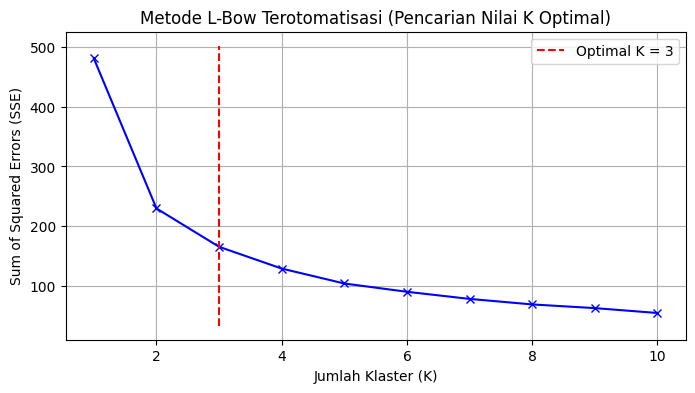

Rekomendasi K-Optimal adalah: 3


In [3]:
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Rekomendasi K-Optimal adalah: {optimal_k}")

### 3. Eksekusi KMeans

In [4]:
print(f"Mengeksekusi K-Means Konvensional untuk K={optimal_k}...")
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
final_labels = kmeans.fit_predict(X_scaled)
final_centroids_scaled = kmeans.cluster_centers_


df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi K-Means Konvensional untuk K=3...


,Nama Usaha,Kepemilkan Tanah Numeric,Omset Numeric,Usia Numeric,Cluster
0,NASYWA SNACK,0,5.0,41,C2
1,WARUNG ABINAYA,2,5.0,41,C1
2,TUNGKU MA ENDANG,2,5.0,53,C1
3,WARUNG BU WIWIK,2,5.0,61,C1
4,WARUNG PNUNG,0,5.0,64,C2
5,KRISNA TRANSPORT,0,5.0,51,C2
6,LAUNDRY WINA,0,5.0,39,C2
7,JP CATERING,0,17.5,45,C2
8,SANDANG TRIAN,3,5.0,41,C1
9,JUALAN ES KELAPA MUDA,3,17.5,40,C1


### 4. Evaluasi & Visualisasi

Menggambar Visualisasi Sebaran Klaster...


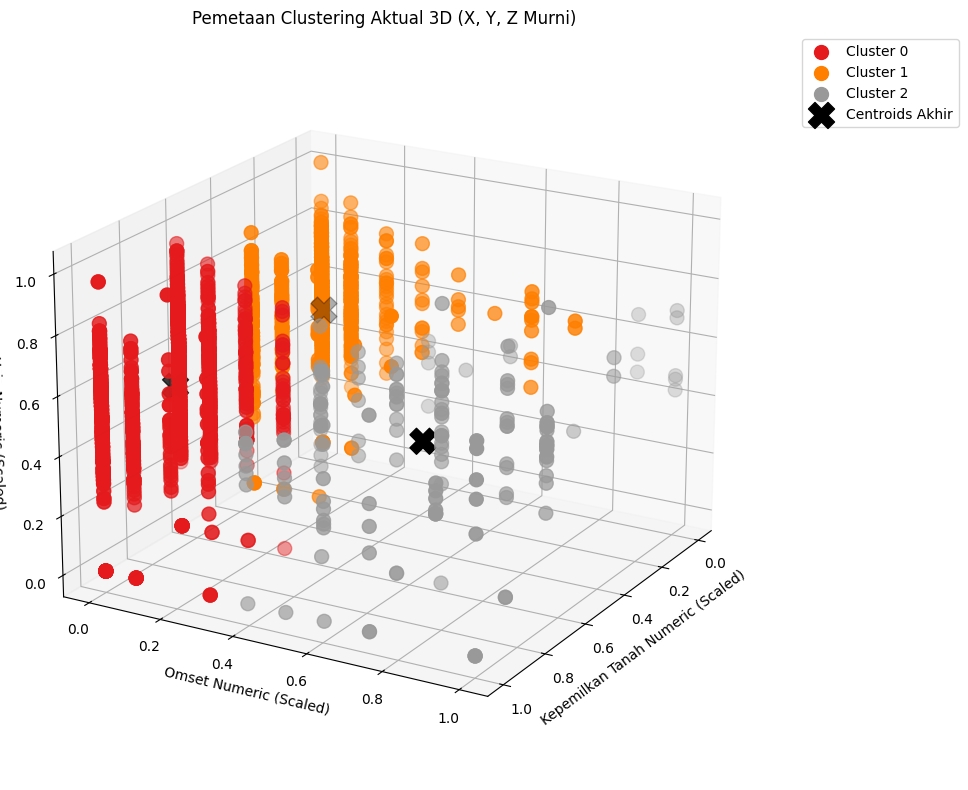


=== EVALUASI METRIK ===
      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.5532
   [Interpretasi]: BUKTINYA BAIK. Terdapat struktur klaster yang masuk akal.

2. Davies-Bouldin Index (DBI): 0.7736
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 2502.5030
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 165.1641
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.3272
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [5]:
print("Menggambar Visualisasi Sebaran Klaster...")
plot_hasil_cluster(X_scaled, final_centroids_scaled, final_labels, fitur_yang_dipakai)

print("\n=== EVALUASI METRIK ===")
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, final_centroids_scaled)

In [6]:
import plotly.express as px

# =========================================================
# 1. Visualisasi 3D Interaktif (Aset vs Omset vs Usia)
# =========================================================
fig_3d_c4 = px.scatter_3d(
    df, 
    x=fitur_yang_dipakai[0], # Kepemilikan Tanah Numeric
    y=fitur_yang_dipakai[1], # Omset Numeric
    z=fitur_yang_dipakai[2], # Usia Numeric
    color='Cluster',
    hover_name='Nama Usaha',
    title="Peta 3D: Ketahanan Aset Fisik dan Finansial UMKM",
    opacity=0.8,
    size_max=12,
    color_discrete_sequence=px.colors.qualitative.Prism
)

fig_3d_c4.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig_3d_c4.show()


# =========================================================
# 2. Bar Chart (Pembandingan Profil Rata-rata Aset)
# =========================================================
# Mengambil rata-rata metrik dari setiap klaster
df_avg_c4 = df.groupby('Cluster')[fitur_yang_dipakai].mean().reset_index()

# Melakukan transformasi data (melt)
df_melted_c4 = df_avg_c4.melt(id_vars='Cluster', value_vars=fitur_yang_dipakai, 
                        var_name='Kategori', value_name='Nilai Rata-rata')

# Menggambar diagram batang
fig_bar_c4 = px.bar(
    df_melted_c4, 
    x='Cluster', 
    y='Nilai Rata-rata', 
    color='Kategori', 
    barmode='group',
    title="Profil Rata-rata Aset Fisik dan Usia per Klaster"
)
fig_bar_c4.show()
